In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings("ignore")

In [6]:
def load_data(data_dir: Path):
    X_train = pd.read_csv(data_dir / "X_train.csv")
    y_train = pd.read_csv(data_dir / "y_train.csv")
    X_test  = pd.read_csv(data_dir / "X_test.csv")   
    y_test  = pd.read_csv(data_dir / "y_test.csv")   

    y_train = y_train.values.ravel()
    y_test  = y_test.values.ravel()                  

    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test  = le.transform(y_test)                 

    print(f"Classes: {le.classes_}  →  0={le.classes_[0]}, 1={le.classes_[1]}")
    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

    return X_train, y_train, X_test, y_test     


In [7]:
def build_pipeline(X: pd.DataFrame):
    numeric_cols     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
    print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    clf = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=500,
    random_state=42
)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    return pipe

Classes: ['Benign' 'Malignant']  →  0=Benign, 1=Malignant
X_train: (148883, 17) | X_test: (63808, 17)
Numeric columns (8): ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Risk_Factor_Score', 'TSH_Nodule_Interact', 'T3_TSH_Ratio']
Categorical columns (9): ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best performing Logistic Regression model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TSH_Level',
                                                   'T3_Level', 'T4_Level',
                                                   'Nodule_Size',
                               

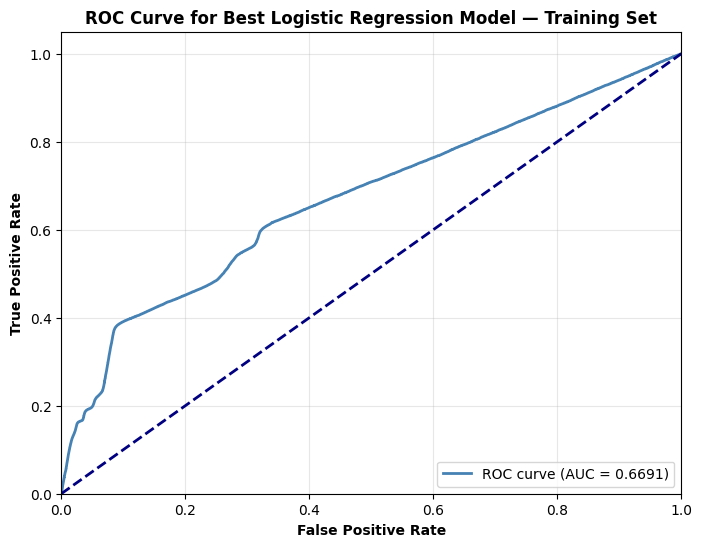

Saved → results/best_logreg_roc_curve_train.png

Error metrics for best model on test set:
Accuracy:              0.7803
Precision (Malignant): 0.6905
Recall (Malignant):    0.1004
F1 (Malignant):        0.1753
AUC:                   0.6683


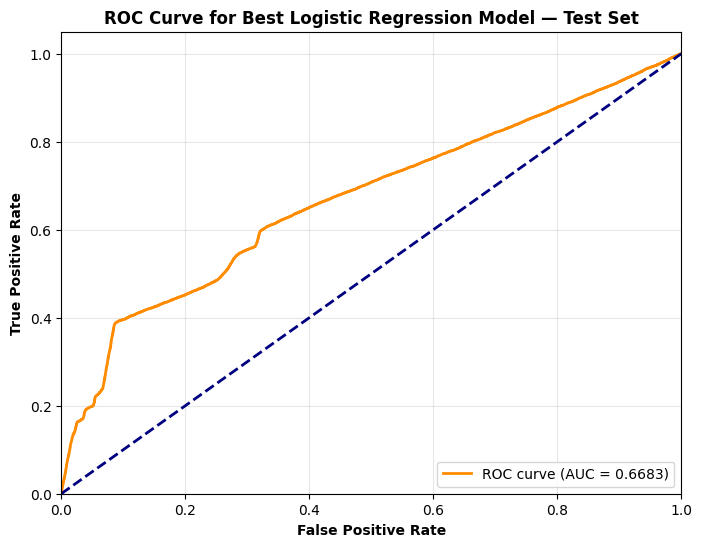

Saved → results/best_logreg_roc_curve_test.png


In [8]:
from matplotlib.pyplot import grid


def main():
    data_dir   = Path("data")
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)

    # Load
    X_train, y_train, X_test, y_test = load_data(data_dir)

    # Build pipeline & grid search
    pipe = build_pipeline(X_train)
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = {
    "classifier__C":        [0.1, 1.0, 10.0],
    "classifier__l1_ratio": [0.0, 1.0]}

    grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv,
                        scoring="roc_auc", refit=True, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print("\nBest performing Logistic Regression model:")
    print(best_model)
    print("\nBest hyperparameters:")
    print(grid.best_params_)
    print(f"Best CV AUC: {grid.best_score_:.4f}")

   # Training Set Metrics (via cross-validation)
    scoring = {
        "accuracy":  make_scorer(accuracy_score),
        "precision": make_scorer(precision_score, pos_label=1),
        "recall":    make_scorer(recall_score,    pos_label=1),
        "f1":        make_scorer(f1_score,        pos_label=1),
        "auc":       "roc_auc"
    }

    scores_best = cross_validate(best_model, X_train, y_train,
                                 cv=cv, scoring=scoring, n_jobs=-1)

    accuracy_train  = scores_best["test_accuracy"].mean()
    precision_train = scores_best["test_precision"].mean()
    recall_train    = scores_best["test_recall"].mean()
    f1_train        = scores_best["test_f1"].mean()
    auc_train       = scores_best["test_auc"].mean()

    print("\nError metrics for best model on training data (averaged across folds):")
    print(f"Accuracy:              {accuracy_train:.4f}")
    print(f"Precision (Malignant): {precision_train:.4f}")
    print(f"Recall (Malignant):    {recall_train:.4f}")
    print(f"F1 (Malignant):        {f1_train:.4f}")
    print(f"AUC:                   {auc_train:.4f}")

    # Training Set ROC Curve (via cross-validation)

    y_prob_train = cross_val_predict(best_model, X_train, y_train,
                                     cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train, pos_label=1)
    roc_auc_train = roc_auc_score(y_train, y_prob_train)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, color="steelblue", lw=2,
             label=f"ROC curve (AUC = {roc_auc_train:.4f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontweight="bold")
    plt.ylabel("True Positive Rate",  fontweight="bold")
    plt.title("ROC Curve for Best Logistic Regression Model — Training Set", fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig("results/best_logreg_roc_curve_train.png", dpi=300)
    plt.show()
    print("Saved → results/best_logreg_roc_curve_train.png")

    # Test Set Metrics

    y_pred_test = best_model.predict(X_test)
    y_prob_test = best_model.predict_proba(X_test)[:, 1]

    accuracy_test  = accuracy_score(y_test,  y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, pos_label=1)
    recall_test    = recall_score(y_test,    y_pred_test, pos_label=1)
    f1_test        = f1_score(y_test,        y_pred_test, pos_label=1)
    auc_test       = roc_auc_score(y_test,   y_prob_test)

    print("\nError metrics for best model on test set:")
    print(f"Accuracy:              {accuracy_test:.4f}")
    print(f"Precision (Malignant): {precision_test:.4f}")
    print(f"Recall (Malignant):    {recall_test:.4f}")
    print(f"F1 (Malignant):        {f1_test:.4f}")
    print(f"AUC:                   {auc_test:.4f}")

    # Test Set ROC Curve
    fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test, pos_label=1)
    roc_auc_test = roc_auc_score(y_test, y_prob_test)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_test, tpr_test, color="darkorange", lw=2,
             label=f"ROC curve (AUC = {roc_auc_test:.4f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate", fontweight="bold")
    plt.ylabel("True Positive Rate",  fontweight="bold")
    plt.title("ROC Curve for Best Logistic Regression Model — Test Set", fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig("results/best_logreg_roc_curve_test.png", dpi=300)
    plt.show()
    print("Saved → results/best_logreg_roc_curve_test.png")


    # save
    best_C        = grid.best_params_["classifier__C"]
    best_l1_ratio = grid.best_params_["classifier__l1_ratio"]

    metrics_df = pd.DataFrame([
        {
            "classifier__C":        best_C,
            "classifier__l1_ratio": best_l1_ratio,
            "set":                  "Train (CV)",
            "accuracy":             accuracy_train,
            "precision":            precision_train,
            "recall":               recall_train,
            "f1":                   f1_train,
            "auc":                  auc_train
        },
        {
            "classifier__C":        best_C,
            "classifier__l1_ratio": best_l1_ratio,
            "set":                  "Test",
            "accuracy":             accuracy_test,
            "precision":            precision_test,
            "recall":               recall_test,
            "f1":                   f1_test,
            "auc":                  auc_test
        }
    ])


if __name__ == "__main__":
    main()